In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);
import SPM_eqs
importlib.reload(SPM_eqs);

In [2]:
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000            # number of time steps
DT = T_HORIZON / (T - 1)   # 3.6036s — fixed for all sims

In [3]:
def get_vals_DC(I0, T=T, t_horizon=T_HORIZON):

    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, t_horizon)   # simulate with t_eval = np.linspace(0, t_horizon, T)

    t_end = sol["Time [s]"].entries[-1]
    t_fixed = np.linspace(0, t_horizon, T)    # fixed 'physical' grid
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    # print(t_fixed[-1], t_query.shape, t_end, valid[-1])

    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)

    return t_fixed, DT, V, I, cn, cp, valid, param

def get_vals_pulse(T=T, t_horizon=T_HORIZON):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(t_horizon, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)

    t_end = sol["Time [s]"].entries[-1]
    t_fixed = np.linspace(0, t_horizon, T)    # fixed 'physical' grid
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    # print(t_fixed[-1], t_query.shape, t_end, valid[-1])

    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)

    return t_fixed, DT, V, I, cn, cp, valid

def get_vals_GRF(T=T, t_horizon=T_HORIZON):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, t_horizon)   # simulate with t_eval = np.linspace(0, t_horizon, T)

    t_end = sol["Time [s]"].entries[-1]
    t_fixed = np.linspace(0, t_horizon, T)    # fixed 'physical' grid
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    # print(t_fixed[-1], t_query.shape, t_end, valid[-1])

    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)

    return t_fixed, DT, V, I, cn, cp, valid  # valid is your loss mask

def gen_data_I_c(B, T=T, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    """
    Generates B trajectories of length T at random constant currents.
    Computes c_dot via finite difference / dt.
    """
    rng = np.random.default_rng(seed)

    V = np.zeros((B, T, 1))
    I = np.zeros((B, T, 1))
    dI = np.zeros((B, T, 1))
    cn = np.zeros((B, T, 1))
    cp = np.zeros((B, T, 1))
    cn_dot = np.zeros((B, T, 1))
    cp_dot = np.zeros((B, T, 1))
    valid = np.zeros((B, T), dtype=bool)

    for i in trange(B):
        if currents == 'DC':
            I0 = float(rng.uniform(I_low, I_high))
            t, dt, V_i, I_i, cn_i, cp_i, valid_i, param = get_vals_DC(I0, T=T, t_horizon=T_HORIZON)
        elif currents == 'pulse':
            t, dt, V_i, I_i, cn_i, cp_i, valid_i = get_vals_pulse(T=T, t_horizon=T_HORIZON)
            pass
        elif currents == 'GRF':
            I0 = float(rng.uniform(I_low, I_high))
            t, dt, V_i, I_i, cn_i, cp_i, valid_i = get_vals_GRF(T=T, t_horizon=T_HORIZON)
        
        V[i, :, 0] = V_i
        I[i, :, 0] = I_i
        cn[i, :, 0] = cn_i
        cp[i, :, 0] = cp_i
        valid[i, :] = valid_i

        # dI(t): backward difference,  dI[0] = 0
        dI[i, 1:, 0] = np.diff(I_i)
        dI[i, 0,  0] = 0.0

        # Proper time derivative (backward/forward diff)
        cn_dot[i, :-1, 0] = np.diff(cn_i) / dt
        cp_dot[i, :-1, 0] = np.diff(cp_i) / dt

        # pad last entry
        cn_dot[i, -1, 0] = cn_dot[i, -2, 0]
        cp_dot[i, -1, 0] = cp_dot[i, -2, 0]

    return I, dI, V, cn, cn_dot, cp, cp_dot, valid, param

In [4]:
B = 1
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = gen_data_I_c(B, T, currents='pulse')

_, _, _, _, _, _, _, _, param = gen_data_I_c(B, T, currents='DC')

100%|██████████| 1/1 [00:00<00:00,  8.31it/s]


In [5]:
# np.savez('data_c_pulse.npz', I=I, dI=dI, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot, valid=valid)

def load_data(path):
    data = np.load(path)
    return data['I'], data['dI'], data['V'], data['cn'], data['cn_dot'], data['cp'], data['cp_dot'], data['valid']

# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('data_c_GRFI.npz')
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('t=5e3_GRF_data_c_dot.npz')
I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('data_c_pulse.npz')
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('Euler_data/data_c_constI.npz')

B = I.shape[0]
# data = np.load('GRF_data_c_dot.npz')

In [6]:
stats = {}

def fit():
    for name, arr in zip(['I', 'dI', 'V', 'cn', 'cn_dot', 'cp', 'cp_dot'], 
                         [I, dI, V, cn, cn_dot, cp, cp_dot]):
        stats[name] = (float(arr.mean()), float(max(arr.std(), 1e-8)))  # Avoid zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = fit()

# Normalize
I_n = transform(I, "I")
dI_n = transform(dI, "dI")
cn_n = transform(cn, "cn")
cp_n = transform(cp, "cp")
cn_dot_n = transform(cn_dot, "cn_dot")
cp_dot_n = transform(cp_dot, "cp_dot")

In [7]:
x = torch.tensor(np.concatenate([I_n, dI_n, cn_n, cp_n], axis=-1), dtype=torch.float32) # [B, T, 4]
y = torch.tensor(np.concatenate([cn_dot_n, cp_dot_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(valid, dtype=torch.float32)

# Flatten time dimension for training
B, T, C = x.shape
x_flat = x.reshape(B * T, C)    # (B*T, 4)
y_flat = y.reshape(B * T, 2)
m_flat = mask.reshape(B * T)

# Split
split = int(0.8 * B)
x_train, x_test = x_flat[:split * T], x_flat[split * T:]
y_train, y_test = y_flat[:split * T], y_flat[split * T:]
mask_train, mask_test = m_flat[:split * T], m_flat[split * T:]

x_train_batch, x_test_batch = x[:split], x[split:]
y_train_batch, y_test_batch = y[:split], y[split:]
mask_train_batch, mask_test_batch = mask[:split], mask[split:]

# Un-normalized for plotting
cn_test = cn[split:]
cp_test = cp[split:]
cn_dot_test = cn_dot[split:]
cp_dot_test = cp_dot[split:]
I_test = I[split:]
dI_test = dI[split:]
mask_test_plot = valid[split:]

V_test = V[split:]

cn_train = cn[:split]
cp_train = cp[:split]
cn_dot_train = cn_dot[:split]
cp_dot_train = cp_dot[:split]
I_train = I[:split]
dI_train = dI[:split]
mask_train_plot = valid[:split]

print('Shapes:', x_train.shape, y_train.shape, mask_train.shape)

batch_size_small = int(B/4)
batch_size_large = int(B*T/4)
train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

Shapes: torch.Size([160000, 4]) torch.Size([160000, 2]) torch.Size([160000])


np.float64(-0.0003921564831996367)

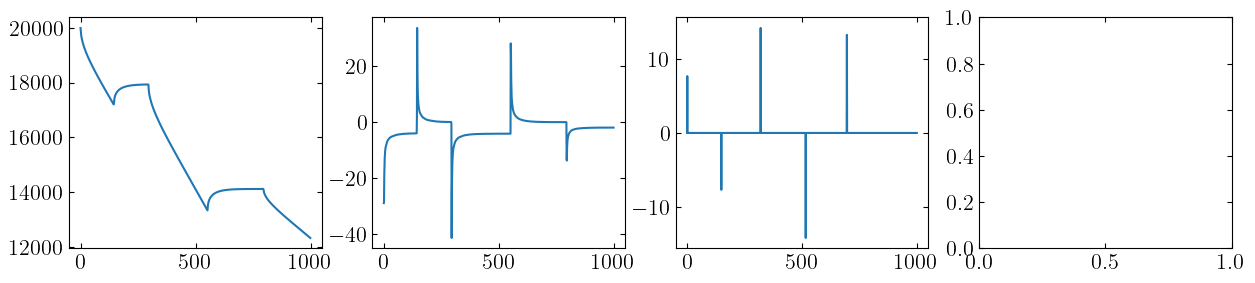

In [8]:

# dc_dI = np.gradient(cn_test[0, :].ravel(), I_test[0, :].ravel())  # Numerical gradient w.r.t. I

# dc_dI = cn_dot_test[0, :] / (dI_test[0, :] + 1e-8)  # Add small epsilon to avoid division by zero

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes[0].plot(cn_test[0, :], label='cn')
axes[1].plot(cn_dot_test[0, :], label='valid')
axes[2].plot(dI_n[0, :], label='dI')
# axes[3].plot(dc_dI, label='cdot')

dI_n[0, :].mean()

In [9]:
''' Mk 1 '''
class Net(nn.Module):
    def __init__(self, input_size=4, hidden_size=128):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # [cn_dot, cp_dot]
        )
    
    def forward(self, x):
        x = self.net(x)
        return x
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [15]:
summary(model=model, input_size=(batch_size_small, 4))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [50, 2]                   --
├─Sequential: 1-1                        [50, 2]                   --
│    └─Linear: 2-1                       [50, 128]                 640
│    └─ReLU: 2-2                         [50, 128]                 --
│    └─Linear: 2-3                       [50, 128]                 16,512
│    └─ReLU: 2-4                         [50, 128]                 --
│    └─Linear: 2-5                       [50, 2]                   258
Total params: 17,410
Trainable params: 17,410
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.87
Input size (MB): 0.00
Forward/backward pass size (MB): 0.10
Params size (MB): 0.07
Estimated Total Size (MB): 0.17

In [10]:
def masked_mse(pred, target, mask):
    # pred, target: (N, 2)   mask: (N)
    err = (pred - target) ** 2    # (B*T, 2)
    m = mask.unsqueeze(-1)        # (B*T, 1) — broadcasts over 2 outputs
    return (err * m).sum() / (m.sum() * 2)

''' Mk 1: Standard training '''
def training(epochs=30):
    history = {"loss": []}
    for ep in range(epochs):
        model.train()
        ep_loss = 0.0

        for x_b, y_b, mask_b in train_loader_flat:
            # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
            pred = model(x_b)   # [B*T, 2]
            loss = masked_mse(pred, y_b, mask_b)
            # print('pred shapes:', pred.shape)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()

        last = ep_loss / len(train_loader_flat)  # Average loss per batch
        history["loss"].append(last)
        print(f"Epoch {ep+1} | loss {last:.3e}")

    return history

''' Mk 2: Distinguish dI peaks and apply loss only there '''
# def training(epochs=30):
#     history = {"loss": []}
#     for ep in range(epochs):
#         model.train()
#         ep_loss = 0.0

#         for x_b, y_b, mask_b in train_loader_flat:
#             # print('batch shapes:', x_b.shape, y_b.shape, mask_b.shape)
#             pred = model(x_b)   # [B*T, 2]
#             loss = masked_mse(pred, y_b, mask_b)
            
#             for i, dI in enumerate(x_b[:, 1]):  # Assuming dI is the second feature
#                 if dI != -0.013627593405544758 and dI > 0:
#                     for t in range(np.arange(0, 100, 10)):  # Example: only consider every 10th time step
#                         mask_b_new = mask_b.clone()
#                         mask_b_new[t] = 1.0  # Set the mask for this specific time step to 1 (i.e., include in loss)
#                         loss = masked_mse(pred, cn_positive, mask_b_new)  # Or some custom loss that emphasizes this point
#                         print(dI.item(), i)

#             # print('pred shapes:', pred.shape)
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()
#             ep_loss += loss.item()

#         last = ep_loss / len(train_loader_flat)  # Average loss per batch
#         history["loss"].append(last)
#         print(f"Epoch {ep+1} | loss {last:.3e}")

#     return history

history = training(epochs=50)

Epoch 1 | loss 9.173e-01
Epoch 2 | loss 6.623e-01
Epoch 3 | loss 4.535e-01
Epoch 4 | loss 3.389e-01
Epoch 5 | loss 3.175e-01
Epoch 6 | loss 3.453e-01
Epoch 7 | loss 3.381e-01
Epoch 8 | loss 3.105e-01
Epoch 9 | loss 3.250e-01
Epoch 10 | loss 3.094e-01
Epoch 11 | loss 3.159e-01
Epoch 12 | loss 3.190e-01
Epoch 13 | loss 3.170e-01
Epoch 14 | loss 3.076e-01
Epoch 15 | loss 2.975e-01
Epoch 16 | loss 3.100e-01
Epoch 17 | loss 3.071e-01
Epoch 18 | loss 2.922e-01
Epoch 19 | loss 3.022e-01
Epoch 20 | loss 3.055e-01
Epoch 21 | loss 2.939e-01
Epoch 22 | loss 2.945e-01
Epoch 23 | loss 3.060e-01
Epoch 24 | loss 2.994e-01
Epoch 25 | loss 3.042e-01
Epoch 26 | loss 3.067e-01
Epoch 27 | loss 2.892e-01
Epoch 28 | loss 2.982e-01
Epoch 29 | loss 2.930e-01
Epoch 30 | loss 2.932e-01
Epoch 31 | loss 2.958e-01
Epoch 32 | loss 2.998e-01
Epoch 33 | loss 2.826e-01
Epoch 34 | loss 2.910e-01
Epoch 35 | loss 2.903e-01
Epoch 36 | loss 2.695e-01
Epoch 37 | loss 2.776e-01
Epoch 38 | loss 2.811e-01
Epoch 39 | loss 2.969

0.2538636364042759


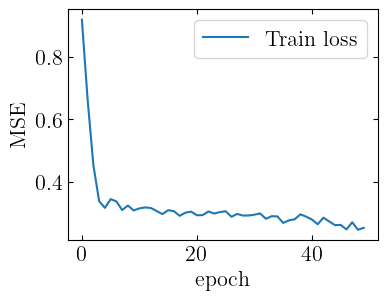

In [11]:
print(history['loss'][-1])
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.plot(history["loss"], label="Train loss")
# ax1.set_yscale("log")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend()

In [12]:
def rollout(idx=0, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        I_true = I_train
        dI_true = dI_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        I_true = I_test
        dI_true = dI_test

    model.eval()

    # Initial un-normalized values for the chosen trajectory
    c0_n = cn_true[idx, 0, 0]
    c0_p = cp_true[idx, 0, 0]

    cn_min = cn_true[idx].min()  # For explicit stopper criterion

    cn_traj = np.zeros(T, dtype=np.float32)
    cp_traj = np.zeros(T, dtype=np.float32)
    cn_dot_traj = np.zeros(T, dtype=np.float32)
    cp_dot_traj = np.zeros(T, dtype=np.float32)
    cn_traj[0] = c0_n
    cp_traj[0] = c0_p

    steps_run = 1

    with torch.no_grad():
        for t in range(T - 1):
            # build normalised input for this step
            I_val  = float(I_true[idx, t, 0])
            dI_val = float(dI_true[idx, t, 0])
            
            x_t = np.array([[
                transform(np.array([[[I_val]]]),  "I")[0,0,0],  # True
                transform(np.array([[[dI_val]]]), "dI")[0,0,0], # True
                transform(np.array([[[cn_traj[t]]]]), "cn")[0,0,0],     # Predicted
                transform(np.array([[[cp_traj[t]]]]), "cp")[0,0,0],]], dtype=np.float32)      # Predicted                  # (1, 4)
            # print('Input x_t shape:', x_t.shape)
            # Predict on initial state (1, 4)
            pred = model(torch.tensor(x_t))              # (1, 2)
            # print(pred)
            dc_n = inverse_transform(pred[0,0].numpy().reshape(1,1,1), "cn_dot")[0,0,0]
            dc_p = inverse_transform(pred[0,1].numpy().reshape(1,1,1), "cp_dot")[0,0,0]

            cn_traj[t+1] = cn_traj[t] + dc_n * DT
            cp_traj[t+1] = cp_traj[t] + dc_p * DT
            cn_dot_traj[t] = dc_n
            cp_dot_traj[t] = dc_p

            steps_run += 1

            # Stop if concentration goes below a threshold
            if cn_traj[t+1] < cn_min:  # Depleated battery
                break

    return cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, steps_run

0.020750454533984615


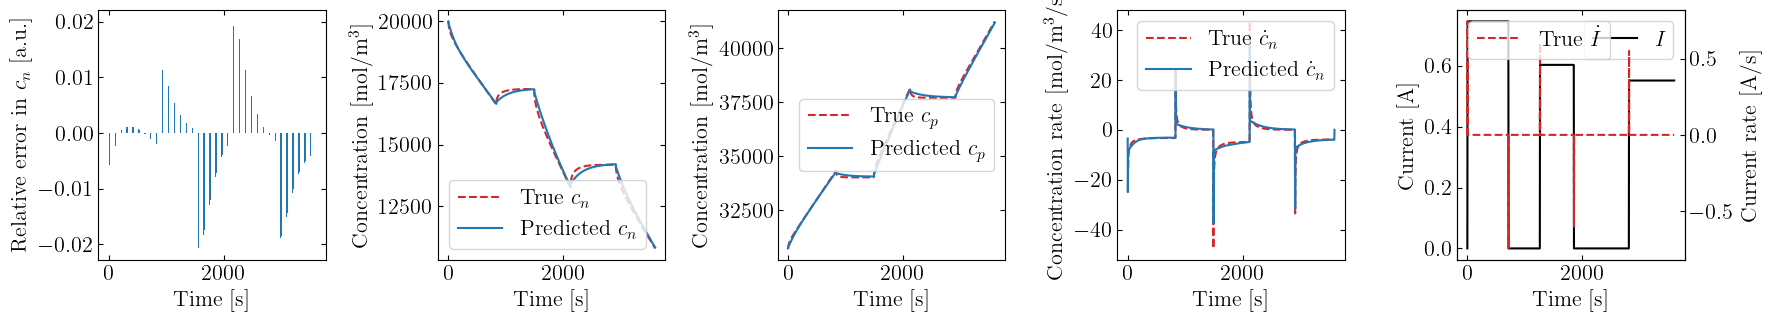

In [13]:
def plot_rollout(idx=0, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        cn_dot_true = cn_dot_train
        cp_dot_true = cp_dot_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        cn_dot_true = cn_dot_test
        cp_dot_true = cp_dot_test
    
    cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run = rollout(idx, on_train=on_train)

    # Ground truth valid length
    n_gt = int(mask_train_plot[idx].sum())          # number of valid GT steps
    n_nn = steps_run                          # number of NN steps before stopping

    t_gt = np.arange(n_gt) * DT             # physical time axis for GT
    t_nn = np.arange(n_nn) * DT             # physical time axis for NN

    fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

    # print('Valid lengths:', n_gt, n_nn)
    # print('Shapes:', cn_train.shape, cp_train.shape, cn_dot_train.shape, cp_dot_train.shape, I_train.shape, dI_train.shape)
    # print(cn_train[0, n_gt:, 0])

    cn_err = (cn_true[idx, :n_nn, 0] - cn_euler[:n_nn]) / (cn_true[idx, :n_nn, 0])
    print(np.max(np.abs(cn_err)))
    # --- cn err ---
    axes[0].bar(t_nn, cn_err, color="tab:blue")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel("Relative error in $c_n$ [a.u.]")

    # --- cn ---
    axes[1].plot(t_gt, cn_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_n$")
    axes[1].plot(t_nn, cn_euler[:n_nn], color="tab:blue", label="Predicted $c_n$")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[1].legend()

    # --- cp ---
    axes[2].plot(t_gt, cp_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_p$")
    axes[2].plot(t_nn, cp_euler[:n_nn], color="tab:blue", label="Predicted $c_p$")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[2].legend()

    # --- cn_dot ---
    axes[3].plot(t_gt, cn_dot_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{c}_n$")
    axes[3].plot(t_nn, cn_dot_euler[:n_nn], color="tab:blue", label="Predicted $\\dot{c}_n$")
    axes[3].set_xlabel("Time [s]")
    axes[3].set_ylabel(r"Concentration rate [mol/m$^3$/s]")
    axes[3].legend()
    
    # --- current ---
    axes[4].plot(t_gt, I_train[idx, :n_gt, 0], color="black", label="$I$")
    axes[4].set_xlabel("Time [s]")
    axes[4].set_ylabel("Current [A]")
    axes[4].legend(loc='upper right')


    # --- dI ---
    axes3_ = axes[4].twinx()
    axes3_.plot(t_gt, dI_train[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{I}$")
    axes3_.set_ylabel(r"Current rate [A/s]")
    axes3_.legend(loc='upper left')

    plt.tight_layout()

    return cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run, n_nn, n_gt, t_gt, t_nn

idx = 2
cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run, n_nn, n_gt, t_gt, t_nn = plot_rollout(idx, on_train=False)

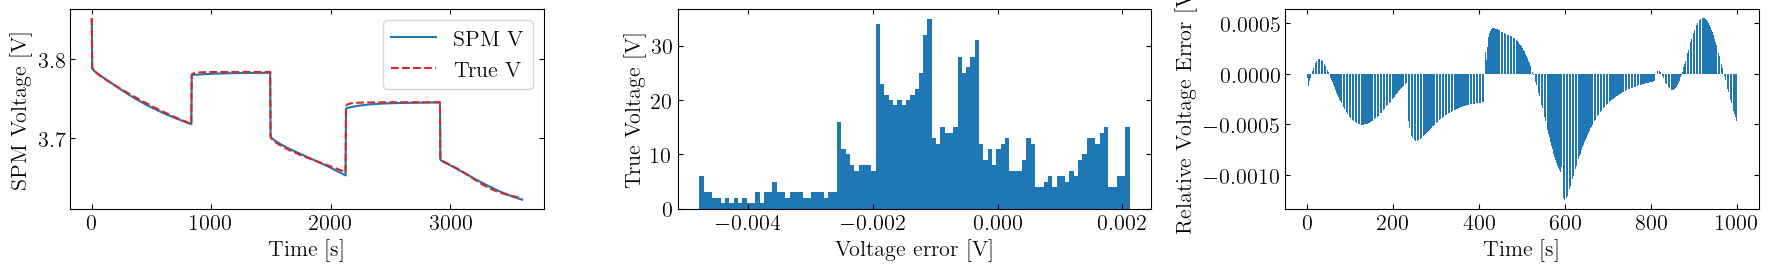

In [14]:
V_t = SPM_eqs.V_terminal(I_test[idx, :, 0], cp_euler[:n_gt], cn_euler[:n_gt], param)

ocv = SPM_eqs.OCV(cn_test[idx, :, 0], cp_test[idx, :, 0])


fig , axes = plt.subplots(1, 3, figsize=(18, 3))
axes[0].plot(t_gt, V_t, label='SPM V')
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("SPM Voltage [V]")
axes[0].plot(t_gt, V_test[idx, :, 0], label='True V', linestyle="dashed", color="tab:red")
axes[0].legend()
axes[1].hist(V_t - V_test[idx, :, 0], bins=100, label='True V')
axes[1].set_xlabel("Voltage error [V]")
axes[1].set_ylabel("True Voltage [V]")
axes[2].bar(np.arange(len(V_t)), (V_t - V_test[idx, :, 0]) / np.max(np.abs(V_test[idx, :, 0])), label='OCV')
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Relative Voltage Error [V]")

plt.tight_layout()